# Notebook 3: Facial Expression Analysis with Hugging Face

In this notebook, we will use a pretrained facial expression recognition model from the Hugging Face Hub.

The goal is to understand how an image classification pipeline can be used for visible facial expression analysis.

> **Important ethical note:** Facial expression analysis does **not** determine a person's true emotional state. It only classifies visible facial expression patterns and may produce incorrect or biased outputs. Use this notebook for educational demonstration only.


## Step 1: Setting up the Environment

We need:

- `transformers` for loading Hugging Face models
- `opencv-python-headless` for face detection
- `Pillow` for image handling
- `matplotlib` for visualization

Run the installation cell below if you are using Google Colab.


In [ ]:
# Optional: Mount Google Drive if your images are stored there.
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# TODO: Install the required packages.
# Hint: You need transformers, opencv-python-headless, Pillow, and matplotlib.

!pip install -q transformers opencv-python-headless Pillow matplotlib

## Step 2: Load a Facial Expression Recognition Model

We will use a Hugging Face `image-classification` pipeline.

Recommended model:

```text
mo-thecreator/vit-Facial-Expression-Recognition
```

This model predicts visible facial expression categories such as happy, sad, angry, surprise, neutral, fear, and disgust.


In [ ]:
# TODO: Import the Hugging Face pipeline function.
from transformers import pipeline
import requests
from PIL import Image
from io import BytesIO

# TODO: Define the model name.
model_name = "..."

# TODO: Create an image-classification pipeline.
face_pipe = ...

# TODO: Test the pipeline with a sample image URL.
# Hint: You can use a public image URL or a local image path.
# Using a public image URL for demonstration
image_path = "..."
img_for_pipeline_test = Image.open(image_path)
print(face_pipe(img_for_pipeline_test))

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[{'label': 'happy', 'score': 0.9961961507797241}, {'label': 'neutral', 'score': 0.0025986323598772287}, {'label': 'surprise', 'score': 0.0005036821239627898}, {'label': 'disgust', 'score': 0.00023273138504009694}, {'label': 'sad', 'score': 0.0001835315633798018}]


## Step 3: Single Face Inference

Now we will test the model on a single face image.

Use one of the following options:

1. A sample image stored in the `photos/` folder
2. A public image URL
3. A manually uploaded image in Colab

For the workshop, it is better to use sample images with appropriate consent or open-license images.


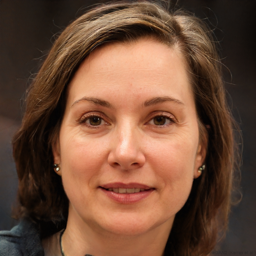

Predicted expression: happy with score: 0.9962
[{'label': 'happy', 'score': 0.9961961507797241}, {'label': 'neutral', 'score': 0.0025986323598772287}, {'label': 'surprise', 'score': 0.0005036821239627898}, {'label': 'disgust', 'score': 0.00023273138504009694}, {'label': 'sad', 'score': 0.0001835315633798018}]


In [ ]:
from PIL import Image
import requests
from io import BytesIO
from IPython.display import display # Import display for Jupyter environment

# TODO: Set the path of a sample face image.
# Example:
# image_path = "photos/sample_face.jpg"
image_path = "..."

# TODO: Load the image.
img = ...

# TODO: Display the image resized to 256x256.
# display(...)

# TODO: Run facial expression prediction.
result = ...

# TODO: Print the top prediction.
# Hint: result[0]["label"] and result[0]["score"]
print(f"Predicted expression: {result[0]['label']} with score: {result[0]['score']:.4f}")
print(result)

## Step 4: Multi-Face Detection with OpenCV Haar Cascade

A facial expression model expects a cropped face image, not necessarily a full classroom or group photo.

In this step, we will:

1. Load a group image
2. Convert it to grayscale
3. Detect faces using OpenCV Haar Cascade
4. Store the detected face bounding boxes

Each face box is represented as:

```text
x, y, width, height
```


In [ ]:
import cv2
import numpy as np
import requests
from io import BytesIO
from PIL import Image # Make sure PIL is imported for Image.open

# TODO: Set the path of a group photo.
# Example:
# image_path = "photos/classroom_photo.png"
image_path = "..."

image_np = np.array(Image.open(image_path))
image = cv2.cvtColor(image_np, cv2.COLOR_RGB2BGR) # Convert RGB to BGR for OpenCV

# TODO: Convert the image to grayscale.
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# TODO: Initialize the Haar Cascade face detector.
# Hint: cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

# TODO: Detect faces.
# Hint: use detectMultiScale(...)
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

# TODO: Print the number of detected faces.
print(f"Detected {len(faces)} faces.")

Detected 7 faces.


## Step 5: Predict Expressions on Cropped Faces

Now we will crop each detected face and send it to the Hugging Face facial expression model.

Pipeline:

```text
Group photo → Face detection → Face crop → PIL image → Facial expression model
```


In [ ]:
from PIL import Image

# TODO: Loop through each detected face.
for (x, y, w, h) in faces:
    # TODO: Crop the face from the original OpenCV image.
    face_crop = image[y:y+h, x:x+w]

    # TODO: Convert BGR to RGB.
    face_rgb = cv2.cvtColor(face_crop, cv2.COLOR_BGR2RGB)

    # TODO: Convert the NumPy array to a PIL image.
    face_pil = Image.fromarray(face_rgb)

    # TODO: Run the facial expression model.
    res = face_pipe(face_pil)

    # TODO: Print the predicted expression and confidence score.
    if res:
        label = res[0]['label']
        score = res[0]['score']
        print(f"Face at ({x},{y},{w},{h}): Predicted expression: {label} (Confidence: {score:.4f})")
    else:
        print(f"Face at ({x},{y},{w},{h}): No prediction.")

Face at (290,437,35,35): Predicted expression: neutral (Confidence: 0.9009)
Face at (183,444,36,36): Predicted expression: happy (Confidence: 0.6819)
Face at (421,458,35,35): Predicted expression: neutral (Confidence: 0.5112)
Face at (585,478,43,43): Predicted expression: neutral (Confidence: 0.6526)
Face at (347,495,58,58): Predicted expression: happy (Confidence: 0.9969)
Face at (71,696,56,56): Predicted expression: happy (Confidence: 0.7200)
Face at (906,922,61,61): Predicted expression: happy (Confidence: 0.2180)


## Step 6: Visualize Detected Faces and Predictions

Finally, we will draw bounding boxes and predicted labels on the original image.

This is useful for understanding which face the model analyzed.


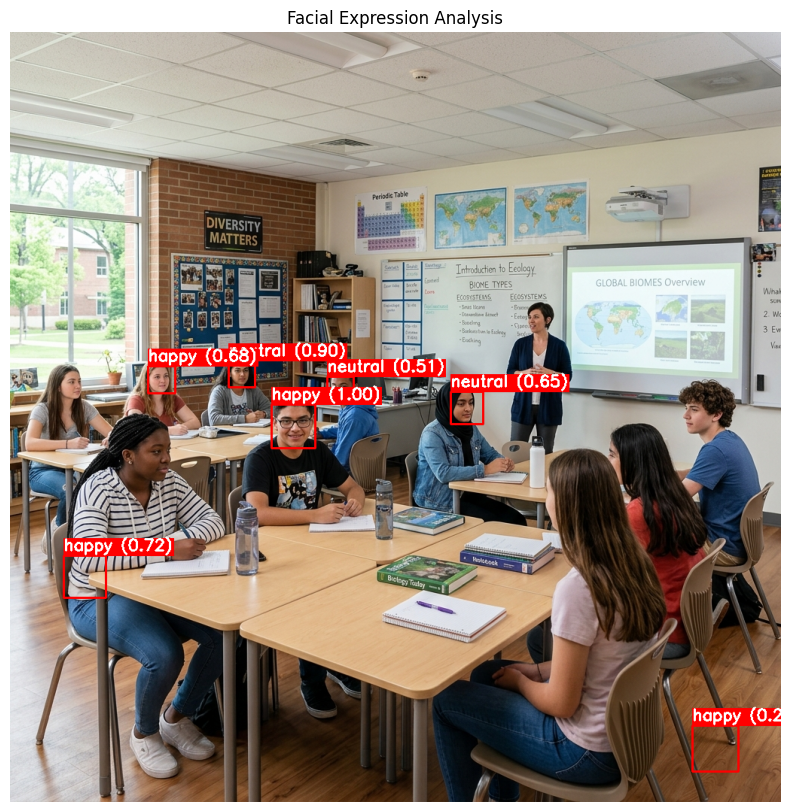

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import cv2

# TODO: Create a copy of the image and convert it to RGB for matplotlib.
img_display = cv2.cvtColor(image.copy(), cv2.COLOR_BGR2RGB)

for (x, y, w, h) in faces:
    # TODO: Crop the face.
    face_crop = image[y:y+h, x:x+w]

    # TODO: Convert to RGB and PIL image.
    face_rgb = cv2.cvtColor(face_crop, cv2.COLOR_BGR2RGB)
    face_pil = Image.fromarray(face_rgb)

    # TODO: Predict expression.
    res = face_pipe(face_pil)

    # TODO: Prepare the label text.
    label = "Unknown"
    if res:
        label = f"{res[0]['label']} ({res[0]['score']:.2f})"

    # TODO: Draw a rectangle around the face.
    # Hint: cv2.rectangle(...)
    cv2.rectangle(img_display, (x, y), (x+w, y+h), (255, 0, 0), 2) # Red rectangle

    # TODO: Put the label above the face.
    # Hint: cv2.putText(...)
    # Calculate text size to position it properly
    (text_width, text_height), baseline = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
    # Draw a filled rectangle as background for the text
    cv2.rectangle(img_display, (x, y - text_height - baseline), (x + text_width, y), (255, 0, 0), cv2.FILLED)
    cv2.putText(img_display, label, (x, y - baseline), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2) # White text

# TODO: Display the final image.
plt.figure(figsize=(14, 10))
plt.imshow(img_display)
plt.axis("off")
plt.title("Facial Expression Analysis")
plt.show()

## Reflection Questions

1. Did the model correctly detect all faces?
2. Were any faces missed? Why might that have happened?
3. Did the facial expression predictions seem reliable?
4. What are the ethical risks of using facial expression analysis?
5. Why should this type of model not be used for high-stakes decisions?
